# Financial Portfolio Analysis Pipeline

**Full pipeline:**
1. User inputs stocks and start date
2. Reddit scraping for posts/comments mentioning those stocks
3. FinGPT sentiment analysis on scraped posts
4. EGARCH + GMM-HMM + LSTM volatility prediction (sentiment included as feature)
5. Markowitz portfolio optimisation (Efficient Frontier)
6. Monte Carlo simulation of portfolio wealth paths


## 0. Install Dependencies

In [1]:
# FIX: added accelerate (required by bitsandbytes for 8-bit model loading)
!pip install -q arch hmmlearn praw yfinance tensorflow scikit-learn tqdm \
             transformers peft bitsandbytes accelerate huggingface_hub torch


## 1. Imports

In [2]:
import os, sys, csv
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from hmmlearn.hmm import GMMHMM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import praw
from datetime import datetime, timezone, timedelta
from typing import List, Dict, Any, Tuple, Optional
from tqdm.auto import tqdm
# FIX: torch imported globally — needed for fingpt_model.parameters() in Step 3
import torch
import warnings
warnings.filterwarnings('ignore')


## Step 1: User Input

Enter each stock ticker one at a time, then `Q` to finish.
Also enter the start date for all downstream analysis.

In [3]:
stocks = []
adding = True
while adding:
    temp = input('Enter a stock ticker (e.g. AAPL). Enter Q to finish: ').strip()
    if temp.upper() == 'Q':
        adding = False
    elif temp:
        stocks.append(temp.upper())

start = input('Enter start date for analysis (YYYY-MM-DD): ').strip()

print(f'Stocks selected : {stocks}')
print(f'Start date      : {start}')


Enter a stock ticker (e.g. AAPL). Enter Q to finish: aapl
Enter a stock ticker (e.g. AAPL). Enter Q to finish: googl
Enter a stock ticker (e.g. AAPL). Enter Q to finish: q
Enter start date for analysis (YYYY-MM-DD): 2023-06-01
Stocks selected : ['AAPL', 'GOOGL']
Start date      : 2023-06-01


## Step 2: Reddit Scraping

Defines all scraper helpers, then runs them using the user's stocks as keywords.

**Credentials:** set `REDDIT_CLIENT_ID`, `REDDIT_CLIENT_SECRET`, and optionally `REDDIT_USER_AGENT` as Colab Secrets (🔑 icon in the left sidebar). Make sure the *Notebook access* toggle is **ON** for each secret.

In [4]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
SUBREDDITS = [
    'wallstreetbets', 'stocks', 'StockMarket',
    'CryptoCurrency', 'finance', 'fintech',
]
MAX_POST_TEXT_CHARS    = 5000
MAX_COMMENT_TEXT_CHARS = 3000
OUT_POSTS_CSV       = 'reddit_posts.csv'
OUT_COMMENTS_CSV    = 'reddit_comments.csv'
OUT_POST_CONCAT_CSV = 'reddit_postid_comments_concat.csv'

# ── AUTH ─────────────────────────────────────────────────────────────────────
from google.colab import userdata
REDDIT_CLIENT_ID     = userdata.get('REDDIT_CLIENT_ID')
REDDIT_CLIENT_SECRET = userdata.get('REDDIT_CLIENT_SECRET')
REDDIT_USER_AGENT    = userdata.get('REDDIT_USER_AGENT') or 'reddit-scraper-script'

if not REDDIT_CLIENT_ID or not REDDIT_CLIENT_SECRET:
    raise ValueError('Missing Reddit credentials. Set them as Colab Secrets.')

reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
)
SGT = timezone(timedelta(hours=8))

# ── HELPERS ──────────────────────────────────────────────────────────────────
def clamp_text(text: Optional[str], max_chars: int) -> str:
    text = (text or '').strip()
    return text if len(text) <= max_chars else text[:max_chars] + ' ...[truncated]'

def extract_post_id(link_id: Optional[str]) -> Optional[str]:
    if not link_id: return None
    s = str(link_id)
    return s[3:] if s.startswith('t3_') else s

def parse_start_date_to_utc_ts(s: str) -> float:
    return datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp()

def keyword_match(text: str, keywords: List[str]) -> bool:
    if not keywords: return True
    t = (text or '').lower()
    return any(k in t for k in keywords)

def write_csv(path: str, rows: List[Dict[str, Any]]) -> None:
    if not rows:
        print(f'Warning: No rows for {path}'); return
    fieldnames = sorted({k for r in rows for k in r.keys()})
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader(); writer.writerows(rows)

# ── SCRAPER ──────────────────────────────────────────────────────────────────
def scrape_since_with_keywords(
    start_ts: float, keywords: List[str],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    posts, comments = [], []
    seen_posts, seen_comments = set(), set()

    for sub in SUBREDDITS:
        sr = reddit.subreddit(sub)
        print(f'Posts: r/{sub}')
        for p in sr.new(limit=None):
            if p.id in seen_posts: continue
            if p.created_utc < start_ts: break
            full_text = f'{p.title} {p.selftext or ""}'
            if not keyword_match(full_text, keywords): continue
            posts.append({
                'post_id'              : p.id,
                'subreddit'            : str(p.subreddit),
                'author'               : str(p.author) if p.author else None,
                'created_utc'          : p.created_utc,
                'created_sgt'          : datetime.fromtimestamp(p.created_utc, tz=SGT).isoformat(),
                'title'                : p.title,
                'selftext'             : clamp_text(p.selftext, MAX_POST_TEXT_CHARS),
                'combined_text'        : clamp_text(full_text,  MAX_POST_TEXT_CHARS),
                'score'                : int(p.score),
                'upvote_ratio'         : getattr(p, 'upvote_ratio', None),
                'num_comments'         : int(p.num_comments),
                'total_awards_received': int(getattr(p, 'total_awards_received', 0) or 0),
                'permalink'            : f'https://reddit.com{p.permalink}',
                'url'                  : getattr(p, 'url', None),
                'over_18'              : bool(getattr(p, 'over_18', False)),
                'stickied'             : bool(getattr(p, 'stickied', False)),
                'locked'               : bool(getattr(p, 'locked', False)),
            })
            seen_posts.add(p.id)

        print(f'Comments: r/{sub}')
        for c in sr.comments(limit=None):
            if c.id in seen_comments: continue
            if c.created_utc < start_ts: break
            body = getattr(c, 'body', '') or ''
            if not keyword_match(body, keywords): continue
            comments.append({
                'comment_id'           : c.id,
                'post_id'              : extract_post_id(getattr(c, 'link_id', None)),
                'parent_id'            : getattr(c, 'parent_id', None),
                'subreddit'            : str(c.subreddit),
                'author'               : str(c.author) if c.author else None,
                'created_utc'          : c.created_utc,
                'created_sgt'          : datetime.fromtimestamp(c.created_utc, tz=SGT).isoformat(),
                'body'                 : clamp_text(body, MAX_COMMENT_TEXT_CHARS),
                'score'                : int(getattr(c, 'score', 0) or 0),
                'total_awards_received': int(getattr(c, 'total_awards_received', 0) or 0),
                'is_submitter'         : bool(getattr(c, 'is_submitter', False)),
                'distinguished'        : getattr(c, 'distinguished', None),
                'permalink'            : f'https://reddit.com{c.permalink}',
            })
            seen_comments.add(c.id)
    return posts, comments

# ── POST-COMMENT CONCAT ───────────────────────────────────────────────────────
def build_post_concat(
    posts: List[Dict[str, Any]], comments: List[Dict[str, Any]]
) -> List[Dict[str, Any]]:
    comments_by_post: Dict[str, List] = {}
    for c in comments:
        pid = c.get('post_id')
        if pid: comments_by_post.setdefault(pid, []).append(c)

    rows = []
    for p in posts:
        pid = p['post_id']
        post_comments = comments_by_post.get(pid, [])
        if not post_comments:
            try:
                sub = reddit.submission(id=pid)
                sub.comments.replace_more(limit=0)
                post_comments = [
                    {'body': c.body, 'created_utc': c.created_utc}
                    for c in sub.comments.list()
                    if (c.body or '').strip() not in ('', '[deleted]', '[removed]')
                ]
            except Exception as e:
                print(f'Could not fetch comments for {pid}: {e}')
        post_comments = sorted(post_comments, key=lambda x: x.get('created_utc') or 0)
        concat = ' ||| '.join(
            [c.get('body','').strip() for c in post_comments if (c.get('body') or '').strip()]
        )
        rows.append({
            'post_id'            : pid,
            'post_text'          : p.get('combined_text', ''),
            'all_comments_concat': concat if concat else None,
        })
    return rows


In [5]:
TICKER_ALIASES = {
    'TSLA'   : ['tsla', 'tesla'],
    'AAPL'   : ['aapl', 'apple'],
    'GOOG'   : ['goog', 'googl', 'google'],
    'GOOGL'  : ['goog', 'googl', 'google'],
    'PLTR'   : ['pltr', 'palantir'],
    'MSFT'   : ['msft', 'microsoft'],
    'AMZN'   : ['amzn', 'amazon'],
    'NVDA'   : ['nvda', 'nvidia'],
    'META'   : ['meta', 'facebook'],
    'BTC-USD': ['btc', 'bitcoin'],
    'ETH-USD': ['eth', 'ethereum'],
}

expanded = set()
for s in stocks:
    expanded.update(TICKER_ALIASES.get(s, [s.lower()]))
keywords = list(expanded)
print(f'Scraping Reddit for keywords: {keywords}')

start_ts = parse_start_date_to_utc_ts(start)
posts, comments = scrape_since_with_keywords(start_ts, keywords)
write_csv(OUT_POSTS_CSV, posts)
write_csv(OUT_COMMENTS_CSV, comments)
post_concat_rows = build_post_concat(posts, comments)
write_csv(OUT_POST_CONCAT_CSV, post_concat_rows)
print(f'Done. Posts: {len(posts)} | Comments: {len(comments)} | Concat rows: {len(post_concat_rows)}')


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Scraping Reddit for keywords: ['goog', 'apple', 'aapl', 'google', 'googl']
Posts: r/wallstreetbets


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Comments: r/wallstreetbets


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

...

Posts: r/fintech


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Comments: r/fintech


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Done. Posts: 258 | Comments: 26 | Concat rows: 258


## Step 3: Sentiment Analysis (FinGPT)

Loads FinGPT (LLaMA 3 8B + LoRA adapters) and runs batched sentiment inference over scraped posts. Results are aggregated into a **daily sentiment signal** fed into the LSTM as extra features.

**Prerequisites:**
- Upload `utils.py` to `/content/utils.py` in Colab
- Set `HF_TOKEN` as a Colab Secret (LLaMA 3 is a gated HuggingFace model)
- Your LoRA weights must be at `./outputs/lora_int8_sentiment_llama`

In [6]:
# FIX: sys.path ensures Colab uses YOUR utils.py, not the pre-installed 'utils' package
import sys
sys.path.insert(0, '/content')

# FIX: HuggingFace login required — LLaMA 3 is a gated model
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

from utils import load_fingpt, sentiment_probs_batch, LABELS #connect utils.py

peft_model = '/content/drive/MyDrive/extracted_lora/outputs/lora_int8_sentiment' #connect lora output file
tokenizer, fingpt_model = load_fingpt(peft_model, 'cuda')

# Load the freshly scraped CSV
df_reddit = pd.read_csv(OUT_POST_CONCAT_CSV)

# Build combined_text: post body + all comments
df_reddit['combined_text'] = df_reddit.apply(
    lambda row: (
        str(row['post_text']) + ' ||| ' + str(row['all_comments_concat'])
        if pd.notna(row['all_comments_concat'])
           and str(row['all_comments_concat']).strip() != ''
        else str(row['post_text'])
    ),
    axis=1,
)
print(f'Loaded {len(df_reddit)} posts for sentiment inference')

# FIX: str() cast avoids torch.device type mismatch inside sentiment_probs_batch
device = str(next(fingpt_model.parameters()).device)
print(f'Model device: {device}')

batch_size = 2  # increase to 16-32 if VRAM > 16 GB
preds, prob_rows = [], []
texts = df_reddit['combined_text'].astype(str).tolist()

for s in tqdm(range(0, len(texts), batch_size), desc='Sentiment inference'):
    batch = texts[s : s + batch_size]
    _, probs = sentiment_probs_batch(
        tokenizer, fingpt_model,
        input_sentences=batch, labels=LABELS,
        max_length=1024, device=device,
    )
    probs_cpu = probs.detach().cpu()
    preds.extend([LABELS[i] for i in probs_cpu.argmax(dim=1).tolist()])
    prob_rows.extend(probs_cpu.tolist())

df_reddit['pred_sentiment'] = preds
df_reddit['p_negative']     = [p[0] for p in prob_rows]
df_reddit['p_neutral']      = [p[1] for p in prob_rows]
df_reddit['p_positive']     = [p[2] for p in prob_rows]
df_reddit.to_csv('reddit_sentiment_results.csv', index=False)
print('Saved reddit_sentiment_results.csv')
display(df_reddit[['post_id','post_text','pred_sentiment',
                   'p_negative','p_neutral','p_positive']].head(10))


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded 258 posts for sentiment inference
Model device: cuda:0


Sentiment inference:   0%|          | 0/129 [00:00<?, ?it/s]

Saved reddit_sentiment_results.csv


,post_id,post_text,pred_sentiment,p_negative,p_neutral,p_positive
0,1rtb3zs,Curious. Has anyone changed their stance on th...,neutral,0.398726,0.580142,0.021132
1,1rt9ftu,Google Fiber will be sold to private equity fi...,negative,0.527370,0.221565,0.251066
2,1rsyo1n,"Gee, no way AAPL can go any lower, better buy ...",negative,0.744618,0.166797,0.088585
3,1rs1b4c,$750k on SM Energy (Undervalued US Oil Produce...,negative,0.425789,0.242607,0.331604
4,1rrz5cp,turned $8k into $18k betting on $MU earnings a...,negative,0.548918,0.293815,0.157268
5,1rrqci3,If you'd invest 10k in wallstreetbets stock pi...,negative,0.789873,0.175557,0.034569
6,1rmg524,WSB Top 10 2026 - March |Symbol|Change since A...,negative,0.759233,0.061837,0.178930
7,1rme2om,Marvell +12% pre-market after Q4 beat. EPS $0....,positive,0.284221,0.250824,0.464955
8,1rm2o1h,ADBE is a War & AI Play: Stock Pitch.PDF TL;DR...,positive,0.331814,0.121118,0.547069
9,1rl47nl,Broadcom +5% after-hours on Q1 2026 earnings b...,positive,0.307196,0.186324,0.506480


In [7]:
# FIX: free FinGPT from GPU memory before LSTM training to avoid VRAM conflict.
# PyTorch (FinGPT ~8 GB) and TensorFlow (LSTM) both compete for the same GPU.
del fingpt_model, tokenizer
torch.cuda.empty_cache()
print('FinGPT freed from GPU. VRAM available for LSTM training.')


FinGPT freed from GPU. VRAM available for LSTM training.


In [8]:
# Aggregate per-post sentiment scores into a daily average signal.
# This DataFrame will be joined into LSTM price data as extra features.
posts_df = pd.read_csv(OUT_POSTS_CSV)
sent_df  = pd.read_csv('reddit_sentiment_results.csv')

merged = sent_df.merge(posts_df[['post_id', 'created_sgt']], on='post_id', how='left')
merged['date'] = pd.to_datetime(merged['created_sgt']).dt.normalize()
merged['date'] = merged['date'].dt.tz_localize(None)

daily_sentiment = (
    merged.groupby('date')[['p_positive', 'p_negative', 'p_neutral']]
    .mean()
)
daily_sentiment.index = pd.to_datetime(daily_sentiment.index)
print(f'Daily sentiment computed for {len(daily_sentiment)} days')
print(daily_sentiment)


Daily sentiment computed for 74 days
            p_positive  p_negative  p_neutral
date                                         
2025-12-05    0.728789    0.002055   0.269156
2025-12-06    0.188413    0.697309   0.114278
2025-12-09    0.496815    0.306391   0.196794
2025-12-10    0.161363    0.341605   0.497032
2025-12-11    0.164599    0.128837   0.706565
...                ...         ...        ...
2026-03-11    0.143084    0.587788   0.269128
2026-03-12    0.112540    0.650287   0.237172
2026-03-13    0.233192    0.427877   0.338931
2026-03-14    0.166867    0.513110   0.320023
2026-03-15    0.886851    0.007643   0.105506

[74 rows x 3 columns]


## Step 4: Volatility Prediction (EGARCH + GMM-HMM + LSTM)

For each stock:
- **GMM-HMM** identifies market regimes (Low / Medium / High volatility)
- **EGARCH** extracts a conditional volatility feature
- **LSTM** combines all features — including daily Reddit sentiment — to forecast next-day annualised volatility

In [9]:
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


In [10]:
def hidden_markov_model_gmm(ticker, start):
    """Fit GMM-HMM on log-returns. Returns (regime_series, prob_dists, transition_matrix)."""
    data = yf.download(ticker, start=start, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data = data.xs(ticker, level=1, axis=1) if ticker in data.columns.levels[1] else data

    data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
    data.dropna(inplace=True)
    X = data['Log_Returns'].values.reshape(-1, 1)

    model = GMMHMM(n_components=3, n_mix=2, covariance_type='diag',
                   n_iter=1000, random_state = 42)
    model.fit(X)

    variances = []
    for i in range(model.n_components):
        # model.weights_[i] is shape (n_mix,)
        # model.covars_[i] is shape (n_mix, n_features)

        # We take the weighted average of the variances in this state
        weighted_var = np.dot(model.weights_[i], model.covars_[i])
        variances.append(weighted_var[0]) # [0] because we only have 1 feature (returns)

    variances = np.array(variances)

    # Sort Low -> High
    sorted_order = np.argsort(variances)
    reorder_map = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted_order)}

    # Predict and Reorder
    hidden_states = model.predict(X)
    sorted_states = np.array([reorder_map[s] for s in hidden_states])
    data['Regime'] = sorted_states

    # 4. Print Parameters
    print(f"--- Regime Parameters for {ticker} (GMM-HMM) ---")
    regime_names = ['Low', 'Medium', 'High']

    probability_distributions = {"Mean":{}, "Standard Deviation": {}}

    for i in range(model.n_components):
        original_idx = sorted_order[i]

        # Calculate weighted mean and weighted std for display
        w_mean = np.dot(model.weights_[original_idx], model.means_[original_idx])[0]
        w_var = np.dot(model.weights_[original_idx], model.covars_[original_idx])[0]
        w_std = np.sqrt(w_var)
        probability_distributions["Mean"][regime_names[i]] = w_mean
        probability_distributions["Standard Deviation"][regime_names[i]] = w_std
        print(f"Regime {i} ({regime_names[i]} Volatility):")
        print(f"  Weighted Mean: {w_mean:.5f}")
        print(f"  Weighted Vol (Std): {w_std:.5f}")
        print("-" * 30)

    # 5. Plotting
    plt.figure(figsize=(14, 8))
    colors = ['green', 'gold', 'red']

    # Plot price
    plt.plot(data.index, data['Close'], color='black', alpha=0.1)

    for i, color in enumerate(colors):
        mask = (data['Regime'] == i)
        # Use scatter to handle gaps better
        plt.scatter(data.index[mask], data['Close'][mask],
                   s=10, c=color, label=f"{regime_names[i]} Volatility", alpha=0.6, edgecolors='none')

    plt.title(f"GMM-HMM Regime Detection for {ticker}", fontsize=16)
    plt.ylabel("Price ($)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    transition_matrix = model.transmat_[sorted_order, :][:, sorted_order]

    print("\nTransition Matrix (State i -> j):")
    print(model.transmat_[sorted_order, :][:, sorted_order])
    return data["Regime"], probability_distributions, transition_matrix

In [11]:
def predict_next_day_volatility_annualised(ticker, start):
    """EGARCH + GMM-HMM + LSTM volatility forecast with sentiment features."""

    # ── 1. Download price data ────────────────────────────────────────────────
    data = yf.download(ticker, start=start)
    if isinstance(data.columns, pd.MultiIndex):
        data = data.xs(ticker, level=1, axis=1, drop_level=True)

    # ── 2. GMM-HMM regimes ───────────────────────────────────────────────────
    data['regime'], probability_distribution, transition_matrix = \
        hidden_markov_model_gmm(ticker, start)

    # ── 3. Feature engineering ───────────────────────────────────────────────
    data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1)) * 100

    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)
    data['target_volatility']    = data['log_returns'].rolling(window=indexer).std().shift(-1)
    data['target_vol_log']       = np.log(data['target_volatility'])
    data['volatility_lag_week']  = data['log_returns'].rolling(5).std().shift(1)
    data['volatility_lag_month'] = data['log_returns'].rolling(22).std().shift(1)
    data['volatility_lag_quarter'] = data['log_returns'].rolling(66).std().shift(1)
    data['absolute_returns_lag'] = abs(data['log_returns'].shift(1))
    log_hl = np.log(data['High'] / data['Low'])
    log_co = np.log(data['Close'] / data['Open'])
    data['garman_klass'] = np.sqrt(
        np.maximum(0, 0.5 * log_hl**2 - (2*np.log(2)-1) * log_co**2)
    ) * 100
    data['vol_change'] = data['Volume'].pct_change()

    # ── 4. Merge daily Reddit sentiment ──────────────────────────────────────
    data.index = pd.to_datetime(data.index).tz_localize(None)  # ensure tz-naive
    data = data.join(daily_sentiment, how='left')
    # FIX: .ffill() replaces deprecated fillna(method='ffill')
    data[['p_positive','p_negative','p_neutral']] = (
        data[['p_positive','p_negative','p_neutral']]
        .ffill()
        .fillna(0.333)
    )

    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)

    # ── 5. Train / test split ────────────────────────────────────────────────
    split    = int(len(data) * 0.8)
    training = data.iloc[:split].copy()
    testing  = data.iloc[split:].copy()

    # ── 6. EGARCH on ORIGINAL (unscaled) log returns ─────────────────────────
    # FIX: EGARCH is fitted here, BEFORE StandardScaler is applied below.
    # Previously egarch was re-fitted on full_data which was already scaled — wrong.
    train_mean = training['log_returns'].mean()
    egarch_train = arch_model(
        training['log_returns'] - train_mean, vol='EGARCH', p=1, q=1, dist='t'
    )
    egarch_fit = egarch_train.fit(disp='off')
    training['garch_volatility'] = egarch_fit.conditional_volatility

    egarch_test = arch_model(
        testing['log_returns'] - train_mean, vol='EGARCH', p=1, q=1, dist='t'
    )
    testing['garch_volatility'] = egarch_test.fix(egarch_fit.params).conditional_volatility

    # ── 7. EGARCH 1-step forecast (on original data, before scaling) ─────────
    # FIX: compute next_garch_vol HERE using original log_returns,
    # before concat+scale corrupts the series.
    full_data_orig = pd.concat([training, testing])  # still unscaled at this point
    next_garch_vol = (
        arch_model(
            full_data_orig['log_returns'] - train_mean,
            vol='EGARCH', p=1, q=1, dist='t'
        )
        .fix(egarch_fit.params)
        .forecast(horizon=1).variance.iloc[-1].values[0] ** 0.5
    )
    # Save the last 10 rows in ORIGINAL scale for the final prediction sequence
    time_steps = 10
    last_seq_orig = full_data_orig[[
        'log_returns','volatility_lag_week','volatility_lag_month',
        'volatility_lag_quarter','garch_volatility','absolute_returns_lag',
        'vol_change','garman_klass','p_positive','p_negative','p_neutral'
    ]].iloc[-time_steps:].copy()
    # Plug in the forecasted garch value for the final row
    last_seq_orig.iloc[-1, last_seq_orig.columns.get_loc('garch_volatility')] = next_garch_vol

    # ── 8. Scale features (AFTER saving last_seq_orig) ───────────────────────
    features = [
        'log_returns','volatility_lag_week','volatility_lag_month',
        'volatility_lag_quarter','garch_volatility','absolute_returns_lag',
        'vol_change','garman_klass',
        'p_positive','p_negative','p_neutral',
    ]

    scaler = StandardScaler()
    training[features] = scaler.fit_transform(training[features])
    testing[features]  = scaler.transform(testing[features])

    X_train, y_train    = create_sequences(training[features], training['target_vol_log'])
    X_test,  y_test_log = create_sequences(testing[features],  testing['target_vol_log'])

    val_split   = int(len(X_train) * 0.9)
    X_tr, X_val = X_train[:val_split], X_train[val_split:]
    y_tr, y_val = y_train[:val_split], y_train[val_split:]

    # ── 9. Build and train LSTM ──────────────────────────────────────────────
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1),
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1,
    )

    # ── 10. Forecast next-day volatility ─────────────────────────────────────
    # FIX: scale last_seq_orig (original-scale data) exactly once.
    # Previously, the code scaled already-scaled full_data a second time — wrong.
    last_seq_scaled   = scaler.transform(last_seq_orig)
    last_seq_reshaped = last_seq_scaled.reshape(1, time_steps, len(features))

    pred_log_vol   = lstm_model.predict(last_seq_reshaped, verbose=0)[0][0]
    pred_daily_vol = np.exp(pred_log_vol)
    annualised_vol = pred_daily_vol * np.sqrt(252 / 5)

    print(f'{ticker} -> Daily vol: {pred_daily_vol:.4f}%  |  Annualised: {annualised_vol:.4f}%')

    current_regime = float(data['regime'].iloc[-1])
    return annualised_vol, transition_matrix, probability_distribution, current_regime



========== AAPL ==========


[*********************100%***********************]  1 of 1 completed


--- Regime Parameters for AAPL (GMM-HMM) ---
Regime 0 (Low Volatility):
  Weighted Mean: -0.00065
  Weighted Vol (Std): 0.01261
------------------------------
Regime 1 (Medium Volatility):
  Weighted Mean: 0.00211
  Weighted Vol (Std): 0.01550
------------------------------
Regime 2 (High Volatility):
  Weighted Mean: -0.01495
  Weighted Vol (Std): 0.03777
------------------------------


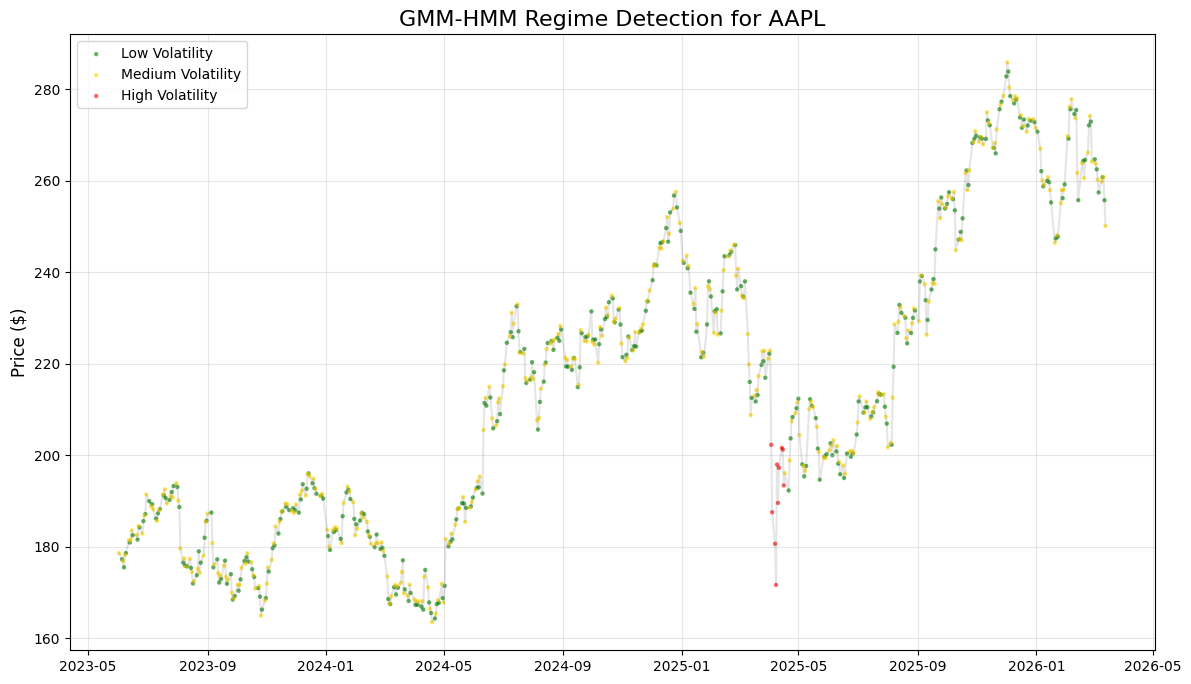


Transition Matrix (State i -> j):
[[1.43860743e-02 9.85613926e-01 1.11505724e-11]
 [9.63829334e-01 3.13501479e-02 4.82051820e-03]
 [7.28175544e-03 1.37855066e-01 8.54863179e-01]]
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.3420 - val_loss: 0.3160
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.3105 - val_loss: 0.2833
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3019 - val_loss: 0.3054
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2801 - val_loss: 0.2814
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.2866 - val_loss: 0.2938
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2694 - val_loss: 0.2675
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2650 - val_loss: 0.2925
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2564 - val_loss: 0.2788
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2551 - val_loss: 0.3056
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step -

[*********************100%***********************]  1 of 1 completed

AAPL -> Daily vol: 1.5855%  |  Annualised: 11.2561%

========== GOOGL ==========


--- Regime Parameters for GOOGL (GMM-HMM) ---
Regime 0 (Low Volatility):
  Weighted Mean: -0.00002
  Weighted Vol (Std): 0.01120
------------------------------
Regime 1 (Medium Volatility):
  Weighted Mean: 0.00287
  Weighted Vol (Std): 0.01846
------------------------------
Regime 2 (High Volatility):
  Weighted Mean: 0.00106
  Weighted Vol (Std): 0.02089
------------------------------


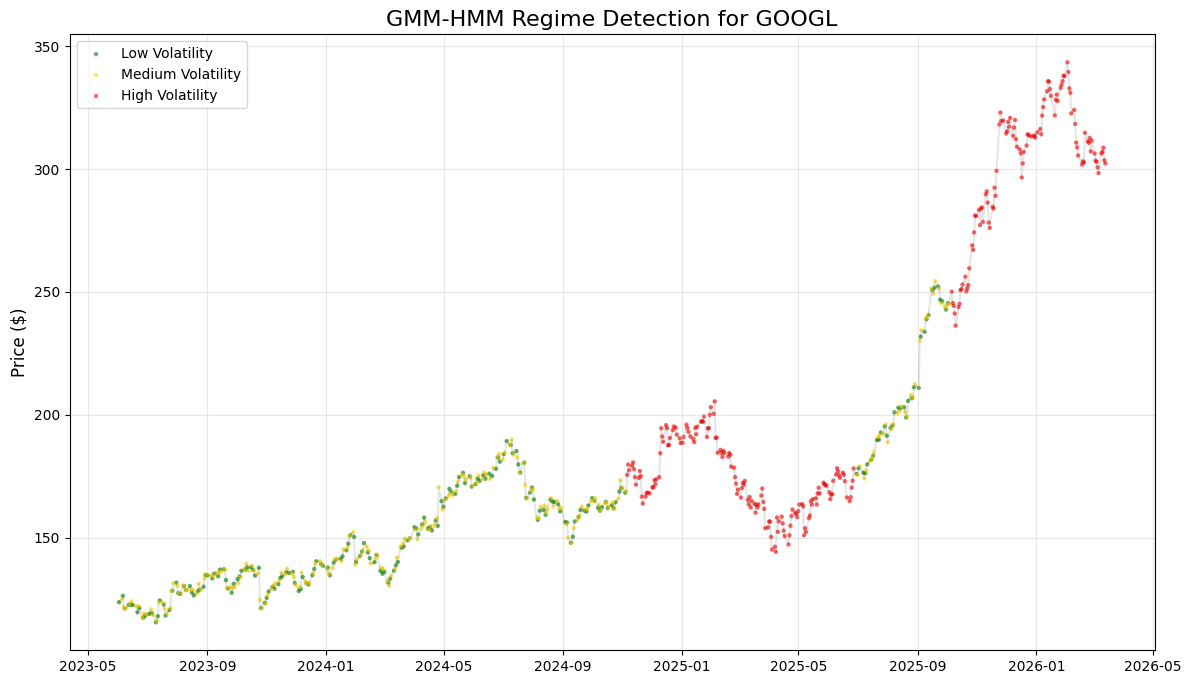


Transition Matrix (State i -> j):
[[4.14762115e-04 9.99088506e-01 4.96732134e-04]
 [9.71325976e-01 7.80634822e-03 2.08676755e-02]
 [1.31560554e-02 2.56303296e-03 9.84280912e-01]]
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.3482 - val_loss: 0.3473
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2877 - val_loss: 0.2954
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2648 - val_loss: 0.3616
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2457 - val_loss: 0.3770
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2350 - val_loss: 0.4066
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2305 - val_loss: 0.3981
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2195 - val_loss: 0.4160
GOOGL -> Daily vol: 1.7489%  |  Annualised: 12.4162%

--- Volatility Summary ---
  AAPL: 11.2561% annualised vol | current regime: 0.0
  GOOGL: 12.4162% annualised vol | current regime: 2.0


In [12]:
predicted_annual_volatilities = {}
transition_matrices           = {}
probability_distributions     = {}
current_regimes               = {}

for stock in stocks:
    print(f'\n========== {stock} ==========')
    ann_vol, trans_mat, prob_dist, cur_regime = predict_next_day_volatility_annualised(stock, start)
    predicted_annual_volatilities[stock] = ann_vol
    transition_matrices[stock]           = trans_mat
    probability_distributions[stock]     = prob_dist
    current_regimes[stock]               = cur_regime

print('\n--- Volatility Summary ---')
for s, v in predicted_annual_volatilities.items():
    print(f'  {s}: {v:.4f}% annualised vol | current regime: {current_regimes[s]}')


## Step 5: Markowitz Portfolio Optimisation

Uses **LSTM-predicted forward-looking volatility** to build the covariance matrix, then simulates 10,000 random portfolios to trace out the Efficient Frontier. The portfolio maximising the Sharpe ratio is selected as optimal.

In [13]:
# Full price history for historical correlation
price_data   = yf.download(stocks, start='1900-01-01')['Close']
returns_data = np.log(price_data / price_data.shift(1))
returns_data.dropna(inplace=True)

# Guard: yfinance returns a Series for single-stock downloads
if isinstance(returns_data, pd.Series):
    returns_data = returns_data.to_frame(name=stocks[0])

correlation_matrix = returns_data.corr()

# Build forward-looking covariance matrix using LSTM-predicted vols
D = np.diag([predicted_annual_volatilities[s] / 100 for s in stocks])
future_variance_matrix = D @ correlation_matrix.values @ D

print('\n--- Forward-Looking Covariance Matrix (Annualised) ---')
print(pd.DataFrame(future_variance_matrix, index=stocks, columns=stocks).round(6))


[*********************100%***********************]  2 of 2 completed


--- Forward-Looking Covariance Matrix (Annualised) ---
           AAPL     GOOGL
AAPL   0.012670  0.007207
GOOGL  0.007207  0.015416


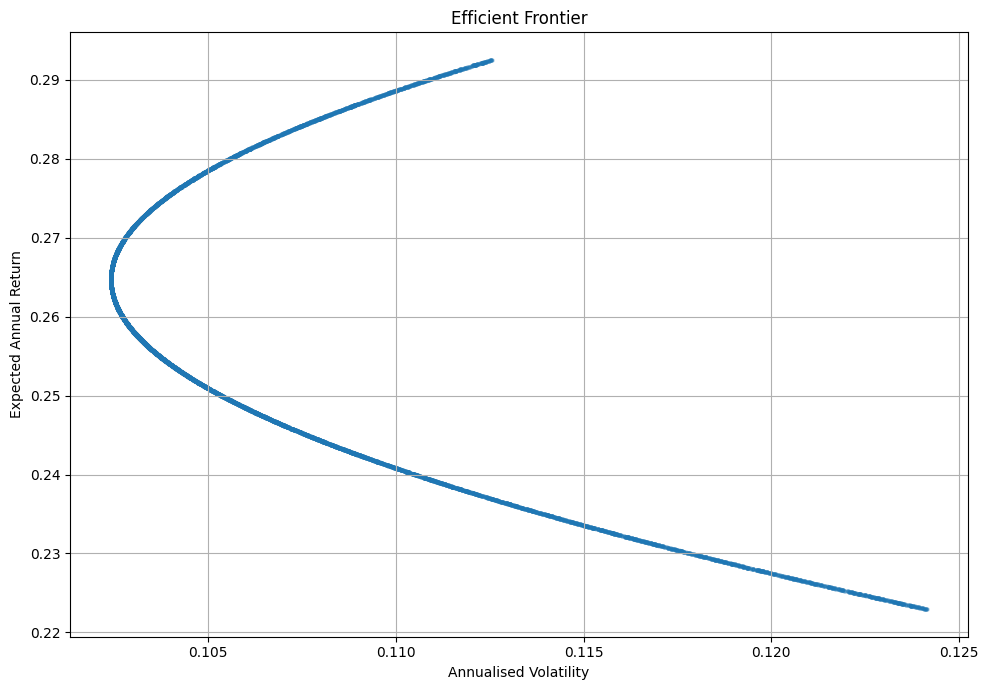

In [14]:
num_stocks, num_portfolios = len(stocks), 10000
risk_free_rate = 0.04
mean_annual_returns = (returns_data.mean() * 252)[stocks]

ret_list, vol_list, alloc_list = [], [], []
for _ in range(num_portfolios):
    w = np.random.random(num_stocks); w /= w.sum()
    alloc_list.append(w)
    ret_list.append(np.dot(w, mean_annual_returns))
    vol_list.append(np.sqrt(w.T @ future_variance_matrix @ w))

data_pf = {'Returns': ret_list, 'Volatilities': vol_list}
for i, sym in enumerate(stocks):
    data_pf[sym + ' Weight'] = [a[i] for a in alloc_list]
portfolio = pd.DataFrame(data_pf)

# Efficient Frontier plot
portfolio.plot.scatter(x='Volatilities', y='Returns', figsize=(10,7),
                       alpha=0.3, s=5, grid=True, title='Efficient Frontier')
plt.xlabel('Annualised Volatility'); plt.ylabel('Expected Annual Return')
plt.tight_layout(); plt.show()


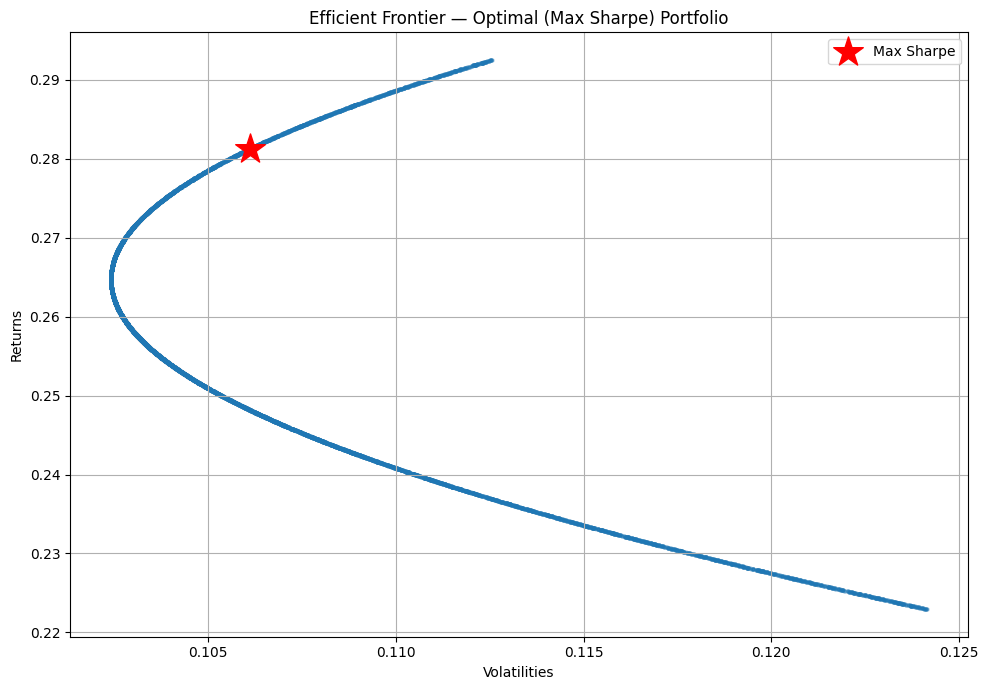

Expected Annual Return : 28.13%
Annualised Volatility  : 10.61%
Sharpe Ratio           : 2.2739


In [15]:
# Optimal portfolio: highest Sharpe ratio
sharpe_idx = ((portfolio['Returns'] - risk_free_rate) / portfolio['Volatilities']).idxmax()
optimal_pf = portfolio.iloc[sharpe_idx]

portfolio.plot.scatter(x='Volatilities', y='Returns', figsize=(10,7),
                       alpha=0.3, s=5, grid=True,
                       title='Efficient Frontier — Optimal (Max Sharpe) Portfolio')
plt.scatter(optimal_pf['Volatilities'], optimal_pf['Returns'],
            color='red', marker='*', s=500, zorder=5, label='Max Sharpe')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Expected Annual Return : {optimal_pf["Returns"]*100:.2f}%')
print(f'Annualised Volatility  : {optimal_pf["Volatilities"]*100:.2f}%')
print(f'Sharpe Ratio           : {(optimal_pf["Returns"]-risk_free_rate)/optimal_pf["Volatilities"]:.4f}')


In [16]:
weights = optimal_pf.iloc[2:].to_numpy()
weights_with_stock_name = dict(zip(stocks, weights))
print('Optimal Portfolio Weights:')
for sym, w in weights_with_stock_name.items():
    print(f'  {sym}: {w*100:.2f}%')


Optimal Portfolio Weights:
  AAPL: 83.82%
  GOOGL: 16.18%


## Step 6: Monte Carlo Simulation

Simulates 252 trading days (1 year) of portfolio wealth paths. Each stock's daily return is sampled from its GMM regime distribution, and regimes transition daily via the Markov matrix.

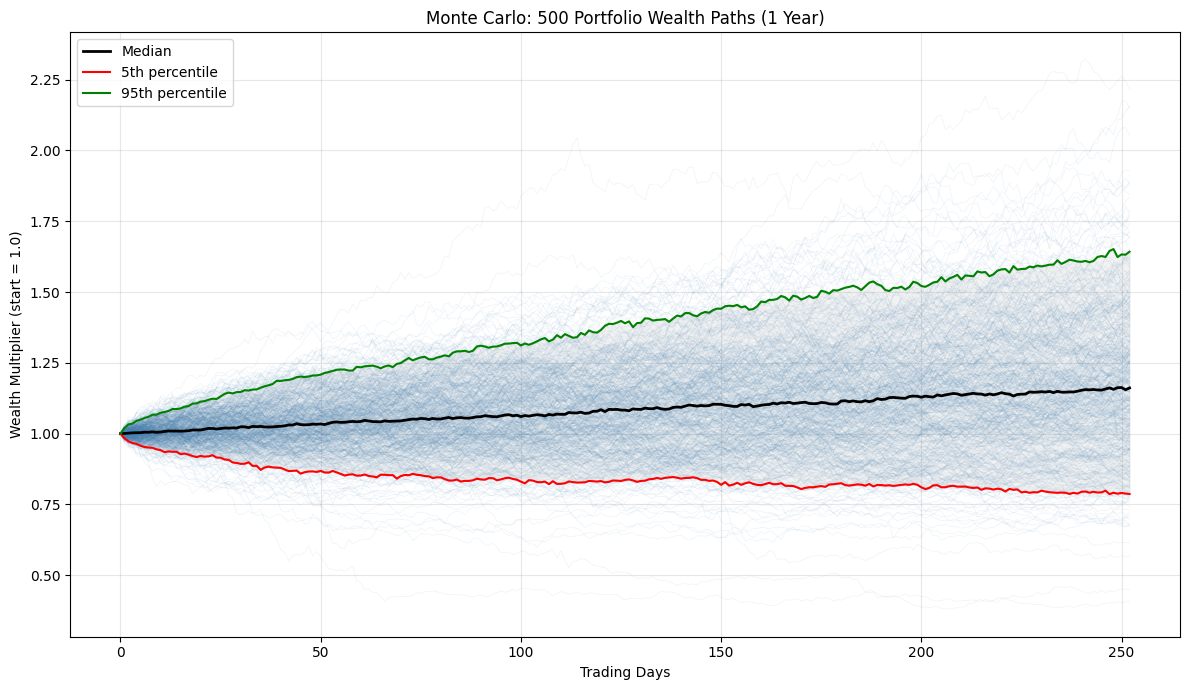

--- After 1 Year (500 simulations) ---
  Median final wealth : 1.1613x
  5th percentile      : 0.7870x
  95th percentile     : 1.6423x
  Probability of loss : 26.0%


In [17]:
FLOAT_TO_STR  = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
REGIME_STATES = [0.0, 1.0, 2.0]


def get_portfolio_return(cur_regimes):
    daily_return = 0.0
    for stock, weight in weights_with_stock_name.items():
        r = FLOAT_TO_STR[float(cur_regimes[stock])]
        mean = probability_distributions[stock]['Mean'][r]
        std  = probability_distributions[stock]['Standard Deviation'][r]
        daily_return += weight * np.random.normal(mean, std)
    return daily_return


def update_regimes(cur_regimes):
    return {
        stock: np.random.choice(REGIME_STATES,
                                p=transition_matrices[stock][int(cur_regimes[stock])])
        for stock in weights_with_stock_name
    }


def simulate_portfolio_year(start_wealth, init_regimes):
    wealth, path = start_wealth, [start_wealth]
    cur = dict(init_regimes)   # copy — never mutate the global
    for _ in range(252):
        wealth *= (1 + get_portfolio_return(cur))
        path.append(wealth)
        cur = update_regimes(cur)
    return path


def monte_carlo(num_paths=500):
    # FIX: run simulations ONCE and reuse for both plotting and percentile bands.
    # Previous version ran num_paths twice (1000 total instead of 500).
    all_paths = np.array([
        simulate_portfolio_year(1.0, current_regimes) for _ in range(num_paths)
    ])  # shape: (num_paths, 253)

    p5  = np.percentile(all_paths, 5,  axis=0)
    p50 = np.percentile(all_paths, 50, axis=0)
    p95 = np.percentile(all_paths, 95, axis=0)
    all_final = all_paths[:, -1]

    plt.figure(figsize=(12, 7))
    for path in all_paths:
        plt.plot(path, color='steelblue', alpha=0.08, linewidth=0.6)
    x = range(253)
    plt.plot(x, p50, color='black', linewidth=2,   label='Median')
    plt.plot(x, p5,  color='red',   linewidth=1.5, label='5th percentile')
    plt.plot(x, p95, color='green', linewidth=1.5, label='95th percentile')
    plt.fill_between(x, p5, p95, alpha=0.1, color='grey')

    plt.title(f'Monte Carlo: {num_paths} Portfolio Wealth Paths (1 Year)')
    plt.xlabel('Trading Days')
    plt.ylabel('Wealth Multiplier (start = 1.0)')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    print(f'--- After 1 Year ({num_paths} simulations) ---')
    print(f'  Median final wealth : {np.median(all_final):.4f}x')
    print(f'  5th percentile      : {np.percentile(all_final,  5):.4f}x')
    print(f'  95th percentile     : {np.percentile(all_final, 95):.4f}x')
    print(f'  Probability of loss : {(all_final < 1.0).mean()*100:.1f}%')


monte_carlo(num_paths=500)
